In [2]:
import pandas as pd

# Load dataset
df = pd.read_csv("sales_dataset (1).csv")

# Show first 5 rows
df.head()

,OrderID,Date,Product,Category,City,Quantity,Price,Total
0,1,2024-03-24,Laptop,Electronics,Islamabad,2,701,1402
1,2,2024-06-25,Keyboard,Accessories,Faisalabad,5,1326,6630
2,3,2024-05-16,Phone,Electronics,Multan,1,1291,1291
3,4,2024-12-17,Headphones,Accessories,Multan,3,1330,3990
4,5,2024-04-23,Keyboard,Accessories,Lahore,3,1305,3915


In [3]:
# Dataset shape (rows, columns)
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

Shape of dataset: (300, 8)

Columns:
Index(['OrderID', 'Date', 'Product', 'Category', 'City', 'Quantity', 'Price',
       'Total'],
      dtype='object')

Data Types:
OrderID      int64
Date        object
Product     object
Category    object
City        object
Quantity     int64
Price        int64
Total        int64
dtype: object

Missing Values:
OrderID     0
Date        0
Product     0
Category    0
City        0
Quantity    0
Price       0
Total       0
dtype: int64


In [4]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Confirm conversion
print(df.dtypes)

# Total Revenue
total_revenue = df['Total'].sum()
print("\nTotal Revenue:", total_revenue)

OrderID              int64
Date        datetime64[ns]
Product             object
Category            object
City                object
Quantity             int64
Price                int64
Total                int64
dtype: object

Total Revenue: 731223


In [5]:
# Top selling product (by quantity)

top_product = (
    df.groupby('Product')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

print("Top Selling Product:")
print(top_product.head(1))

Top Selling Product:
Product
Headphones    178
Name: Quantity, dtype: int64


In [6]:
# Highest revenue generating city

city_revenue = (
    df.groupby('City')['Total']
    .sum()
    .sort_values(ascending=False)
)

print("Highest Revenue City:")
print(city_revenue.head(1))

Highest Revenue City:
City
Multan    162048
Name: Total, dtype: int64


In [7]:
# Category-wise revenue

category_revenue = (
    df.groupby('Category')['Total']
    .sum()
    .sort_values(ascending=False)
)

print("Category-wise Revenue:")
print(category_revenue)

Category-wise Revenue:
Category
Electronics    477757
Accessories    253466
Name: Total, dtype: int64


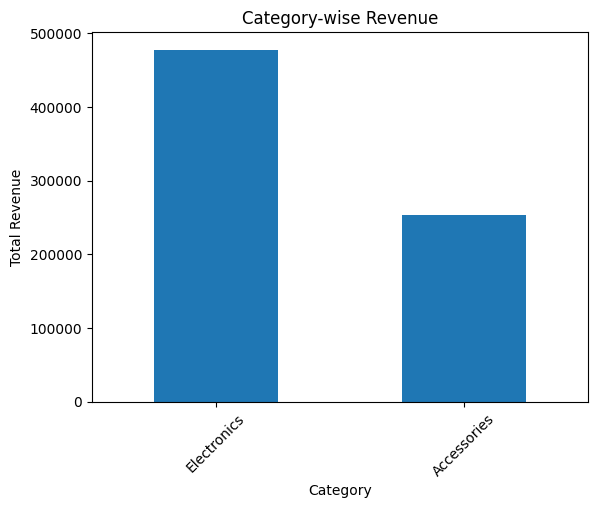

In [8]:
import matplotlib.pyplot as plt

# Plot bar chart
category_revenue.plot(kind='bar')

plt.title("Category-wise Revenue")
plt.xlabel("Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()

In [9]:
# Create Month column
df['Month'] = df['Date'].dt.to_period('M')

# Monthly revenue
monthly_revenue = df.groupby('Month')['Total'].sum()

print(monthly_revenue)

Month
2024-01    64679
2024-02    39997
2024-03    41364
2024-04    40213
2024-05    73942
2024-06    68923
2024-07    67701
2024-08    73985
2024-09    38172
2024-10    73312
2024-11    61586
2024-12    87349
Freq: M, Name: Total, dtype: int64


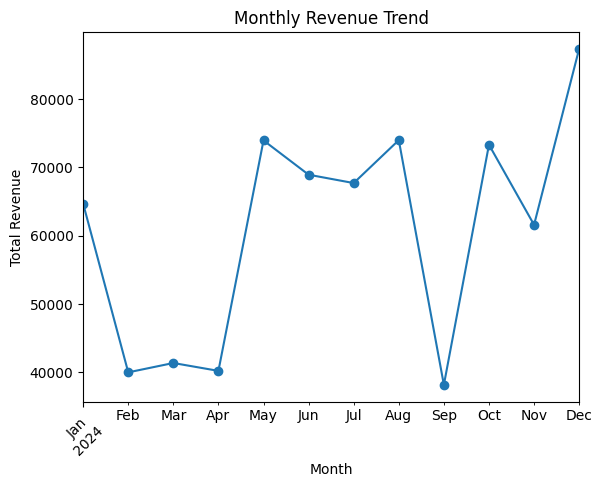

In [10]:
import matplotlib.pyplot as plt

monthly_revenue.plot(kind='line', marker='o')

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.show()